# Density-based spatial clustering of applications with noise (DBSCAN)
## Why do we need a Density-Based clustering algorithm like DBSCAN when we already have K-means clustering?
[Credit](https://www.kdnuggets.com/2020/04/dbscan-clustering-algorithm-machine-learning.html)

### Problems with K-means
1. K-Means clustering may cluster loosely related observations together. Every observation becomes a part of some cluster eventually, even if the observations are scattered far away in the vector space.
2. Another challenge with k-means is that you need to specify the number of clusters (“k”) in order to use it.

![image_dbscane_kmean](https://miro.medium.com/max/1339/0*xu3GYMsWu9QiKNOo.png)

**Density-Based Clustering** refers to unsupervised learning methods that identify distinctive groups/clusters in the data, based on the idea that a cluster in data space is a contiguous region of high point density, separated from other such clusters by contiguous regions of low point density.

**Density-Based Spatial Clustering of Applications with Noise (DBSCAN)** is a base algorithm for density-based clustering. It can discover clusters of different shapes and sizes from a large amount of data, which is containing noise and outliers.

The DBSCAN algorithm uses two hyperparameters:

- **minPts:** The minimum number of points (a threshold) clustered together for a region to be considered dense.
- **eps (ε):** A distance measure that will be used to locate the points in the neighborhood of any point.

There are three types of points after the DBSCAN clustering is complete:
![dbscan1](https://miro.medium.com/max/627/1*yT96veo7Zb5QeswV7Vr7YQ.png)

### Algorithmic steps for DBSCAN clustering

- The algorithm proceeds by arbitrarily picking up a point in the dataset (until all points have been visited).
- If there are at least `minPoint` points within a radius of `ε` to the point then we consider all these points to be part of the same cluster.
- The clusters are then expanded by recursively repeating the neighborhood calculation for each neighboring point

![steps](https://miro.medium.com/proxy/1*tc8UF-h0nQqUfLC8-0uInQ.gif)

### Hyper-parameters
Every data mining task has the problem of parameters. Every parameter influences the algorithm in specific ways. For DBSCAN, the parameters `ε` and `minPts` are needed.

**minPts**

There is no automatic way to determine the **MinPts** value for DBSCAN. Ultimately, the **MinPts** value should be set using domain knowledge and familiarity with the data set. However, here are a few rules of thumb for selecting the **MinPts** value:

- The larger the data set, the larger the value of **MinPts** should be
- If the data set is noisier, choose a larger value of **MinPts**
- Generally, **MinPts** should be greater than or equal to the dimensionality of the data set
- For 2-dimensional data, use DBSCAN’s default value of **MinPts** = 4 (Ester et al., 1996).
- If your data has more than 2 dimensions, choose **MinPts** = 2*dim, where dim= the dimensions of your data set (Sander et al., 1998).


**Epsilon (ε)**

The value for ε can then be chosen by using a k-distance graph.

This technique calculates the average distance between each point and its k nearest neighbors, where **k = the MinPts** value you selected.

The average k-distances are then plotted in ascending order on a k-distance graph. You’ll find the optimal value for **ε** at the point of maximum curvature (i.e. where the graph has the greatest slope).

For more information on "k-distance graph" [read here](https://towardsdatascience.com/machine-learning-clustering-dbscan-determine-the-optimal-value-for-epsilon-eps-python-example-3100091cfbc)

Number of clusters: 2
Silhouette Coefficient: 0.195


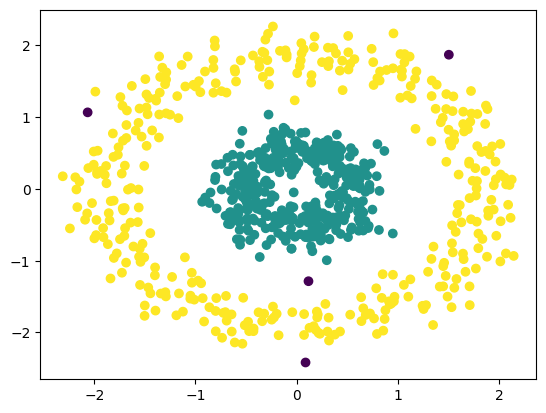

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import metrics
from sklearn.datasets import make_circles
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN

X, y = make_circles(n_samples=750, factor=0.3, noise=0.1)
X = StandardScaler().fit_transform(X)

db = DBSCAN(eps=0.3, min_samples=4)

y_pred = db.fit_predict(X)

plt.scatter(X[:,0], X[:,1], c=y_pred)
print('Number of clusters: {}'.format(len(set(y_pred[np.where(y_pred != -1)]))))
print("Silhouette Coefficient: %0.3f"
      % metrics.silhouette_score(X, db.labels_))
# Silhouette Coefficient or silhouette score is a metric used to calculate the goodness of a clustering technique. Its value ranges from -1 to 1.
# 1: Means clusters are well apart from each other and clearly distinguished.
# 0: Means clusters are indifferent, or we can say that the distance between clusters is not significant.
# -1: Means clusters are assigned in the wrong way.

**ทดลองทำ K-means Clustering กับ dataset นี้ดู**

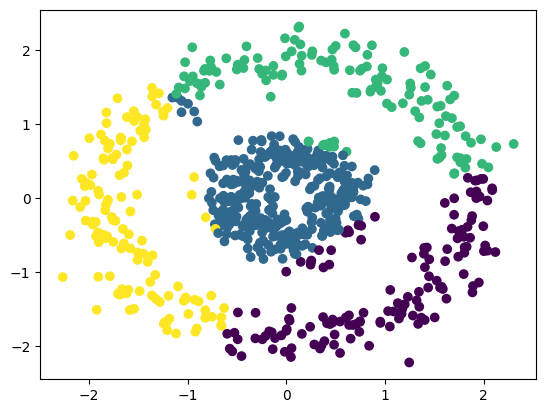

In [2]:
X, y = make_circles(n_samples=750, factor=0.3, noise=0.1)
X = StandardScaler().fit_transform(X)

from sklearn.cluster import KMeans
# Do K-means
kmeans = KMeans(n_clusters = 4, init='k-means++', n_init='auto')
kmeans.fit(X)

y_pred = kmeans.fit_predict(X)

plt.scatter(X[:,0], X[:,1], c=y_pred)

**EX: ทดลองทำ heirarchical clustering กับ dataset นี้ดูและทำการวาด scatter plot ออกมา**

In [3]:
# your code here


In [4]:
import pandas as pd

data_scaled = pd.DataFrame(X)
data_scaled.head()

,0,1
0,-0.492443,1.798233
1,-0.102480,0.443042
2,-0.505191,-0.252827
3,-1.758177,0.520694
4,0.069057,0.793288


In [5]:
from sklearn.cluster import AgglomerativeClustering



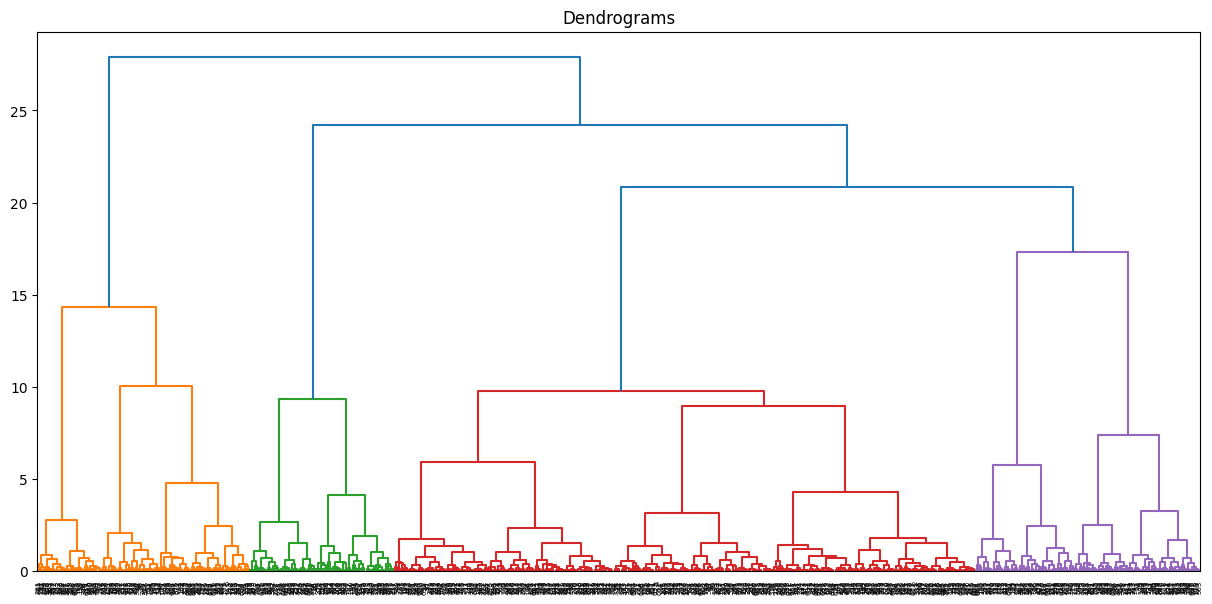

In [6]:
import scipy.cluster.hierarchy as shc
plt.figure(figsize=(15, 7))
plt.title("Dendrograms")
dend = shc.dendrogram(shc.linkage(data_scaled, method='ward'))



In [7]:
from sklearn.cluster import AgglomerativeClustering
cluster = AgglomerativeClustering(n_clusters=5, metric='euclidean', linkage='ward')
y_pred = cluster.fit_predict(data_scaled)

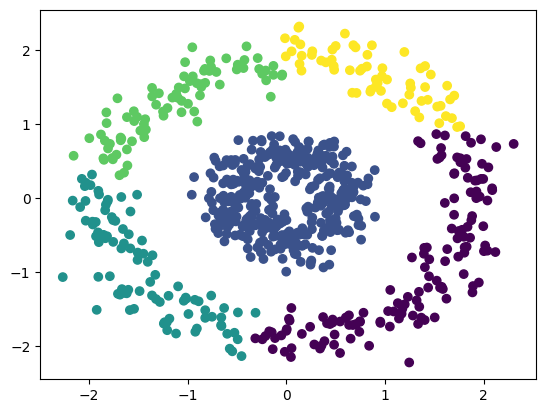

In [8]:
plt.scatter(X[:,0], X[:,1], c=y_pred)

In [9]:
from sklearn import metrics
print("Silhouette Coefficient: %0.3f"
      % metrics.silhouette_score(X, cluster.labels_))

Silhouette Coefficient: 0.420


The **Silhouette Coefficient** is calculated using the mean intra-cluster distance (a) and the mean nearest-cluster distance `(b)` for each sample. The Silhouette Coefficient for a sample is `(b - a) / max(a, b)`. To clarify, b is the distance between a sample and the nearest cluster that the sample is not a part of.

The best value is 1 and the worst value is -1. Values near 0 indicate overlapping clusters. Negative values generally indicate that a sample has been assigned to the wrong cluster, as a different cluster is more similar.